# So sánh mô hình phân loại độ tươi rau củ quả

Notebook này tổng hợp kết quả đã sinh bởi pipeline trong `src/`, mô tả preprocessing và ba kiến trúc M1/M2/M3, đối chiếu các chỉ số trên test set, trực quan hóa learning curves/confusion matrix, sau đó đưa ra kết luận và các điểm cần lưu ý từ EDA.

> Notebook chỉ đọc các artifact trong `results/` và `data/splits/`; không huấn luyện lại model. Nếu chưa chạy đánh giá, hãy chạy `python -m src.evaluate --model M1|M2|M3` trước.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

_candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p.resolve() for p in _candidates if (p / "src").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Không tìm thấy project root chứa thư mục src/. Hãy mở notebook trong repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
METRICS = RESULTS / "metrics"
PLOTS = RESULTS / "plots"
print(f"Project root: {ROOT}")

Project root: D:\EP16\Deep Neural Networks\DL-ImageClassification


## 1. Tóm tắt preprocessing

- Ảnh được đọc và chuyển về RGB; EXIF orientation được chuẩn hóa, alpha được ghép lên nền cố định.
- `ResizeWithPadding` đưa ảnh vào khung vuông 128×128 cho M1/M2 và 224×224 cho M3, giữ tỷ lệ và không crop/méo đối tượng.
- Train dùng augmentation nhẹ: horizontal flip, rotation ±10°, brightness/contrast/saturation ±15°. Không đổi hue vì màu có thể là tín hiệu của độ tươi.
- Validation/test chỉ resize + tensor hóa + chuẩn hóa theo ImageNet (`mean=(0.485, 0.456, 0.406)`, `std=(0.229, 0.224, 0.225)`).
- Dữ liệu được chia stratified 70/15/15 theo 28 lớp, seed 42. SHA-256 được dùng để phát hiện ảnh trùng; duplicate khác nhãn bị loại khỏi split để tránh leakage.

Các chi tiết trên được triển khai trong [`src/preprocessing.py`](../src/preprocessing.py) và [`src/data.py`](../src/data.py).

In [2]:
split_frames = {}
for split in ("train", "val", "test"):
    path = ROOT / "data" / "splits" / f"{split}.csv"
    if path.is_file():
        split_frames[split] = pd.read_csv(path)
if not split_frames:
    raise FileNotFoundError("Chưa có data/splits/*.csv. Hãy chạy python -m src.preprocessing trước.")
split_sizes = pd.DataFrame({"split": list(split_frames), "images": [len(df) for df in split_frames.values()]})
display(split_sizes)
counts = pd.concat([df["class_name"].value_counts().rename(split) for split, df in split_frames.items()], axis=1).fillna(0).astype(int)
display(counts.head())
print(f"Tổng ảnh trong split: {int(split_sizes['images'].sum()):,}; số lớp: {counts.shape[0]}")

,split,images
0,train,20510
1,val,4381
2,test,4395


,train,val,test
class_name,,,
Apple__Rotten,2051,439,440
Banana__Rotten,1960,420,420
Apple__Healthy,1706,366,366
Mango__Rotten,1573,340,334
Orange__Rotten,1525,328,333


Tổng ảnh trong split: 29,286; số lớp: 28


### Lưu ý cần giữ từ EDA

1. Đây là bài toán 28 lớp (14 loại rau/củ/quả × Healthy/Rotten), vì vậy accuracy đơn thuần chưa đủ; macro precision/recall/F1 quan trọng để mỗi lớp có trọng số ngang nhau.
2. Cần kiểm tra mất cân bằng lớp và các lớp có hình thức gần nhau (đặc biệt cùng một loại nhưng khác trạng thái). Báo cáo per-class F1 và confusion matrix nên được xem cùng nhau.
3. Kích thước/aspect ratio và mode màu không đồng nhất là lý do dùng RGB + padding thay vì resize méo. Ảnh lỗi, ảnh trùng và duplicate khác nhãn phải được kiểm tra trước khi split.
4. Màu sắc có thể mang thông tin Healthy/Rotten nhưng cũng dễ bị ảnh hưởng bởi ánh sáng/nền; augmentation được giữ nhẹ và không random hue để tránh phá tín hiệu, đồng thời cần thận trọng khi diễn giải khả năng tổng quát hóa ngoài dataset.
5. Split theo file/hash giúp giảm leakage, nhưng kết quả vẫn là đánh giá trên cùng domain với dataset Kaggle; nên có external test set nếu triển khai thực tế.

## 2. Mô tả các model

| Model | Kiến trúc | Input | Vai trò |
|---|---|---:|---|
| **M1 – Simple NN** | Flatten → Linear 256 → ReLU/Dropout → Linear 128 → ReLU/Dropout → 28 logits | 128×128 | Baseline, không khai thác cấu trúc không gian tốt |
| **M2 – Deep CNN** | 3 convolution blocks (32/64/128 channels, BatchNorm, ReLU, MaxPool) → AdaptiveAvgPool → Dropout → Linear | 128×128 | Học đặc trưng không gian trực tiếp từ ảnh |
| **M3 – Transfer Learning** | MobileNetV2 pretrained, thay classifier thành 28 lớp; freeze backbone rồi fine-tune | 224×224 | Tận dụng đặc trưng ImageNet, tối ưu hiệu năng |

M1/M2 dùng Adam và weighted cross-entropy; checkpoint được chọn theo validation macro-F1. M3 huấn luyện head trước, sau đó mở backbone với learning rate nhỏ hơn. Chi tiết nằm ở [`src/train.py`](../src/train.py), [`src/models/simple_nn.py`](../src/models/simple_nn.py), [`src/models/cnn.py`](../src/models/cnn.py) và [`src/models/transfer.py`](../src/models/transfer.py).

In [3]:
def load_json(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else None

models = ["M1", "M2", "M3"]
evaluation = {m: load_json(METRICS / f"{m}_evaluation.json") for m in models}
training = {m: load_json(METRICS / f"{m}_training.json") for m in models}
missing = [m for m in models if evaluation[m] is None]
if missing:
    print("Thiếu evaluation JSON cho:", ", ".join(missing))
rows = []
for m in models:
    result = evaluation[m]
    if result:
        rows.append({"Model": m, "Accuracy": result["accuracy"], "Macro precision": result["macro_precision"], "Macro recall": result["macro_recall"], "Macro F1": result["macro_f1"]})
comparison = pd.DataFrame(rows).set_index("Model")
display(comparison.style.format("{:.4f}"))

,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
M1,0.4253,0.3990,0.4815,0.3928
M2,0.7060,0.6493,0.7136,0.6583
M3,0.9832,0.9729,0.9766,0.9745


,Accuracy,Macro precision,Macro recall,Macro F1
Model,,,,
M1,0.4253,0.3990,0.4815,0.3928
M2,0.7060,0.6493,0.7136,0.6583
M3,0.9832,0.9729,0.9766,0.9745


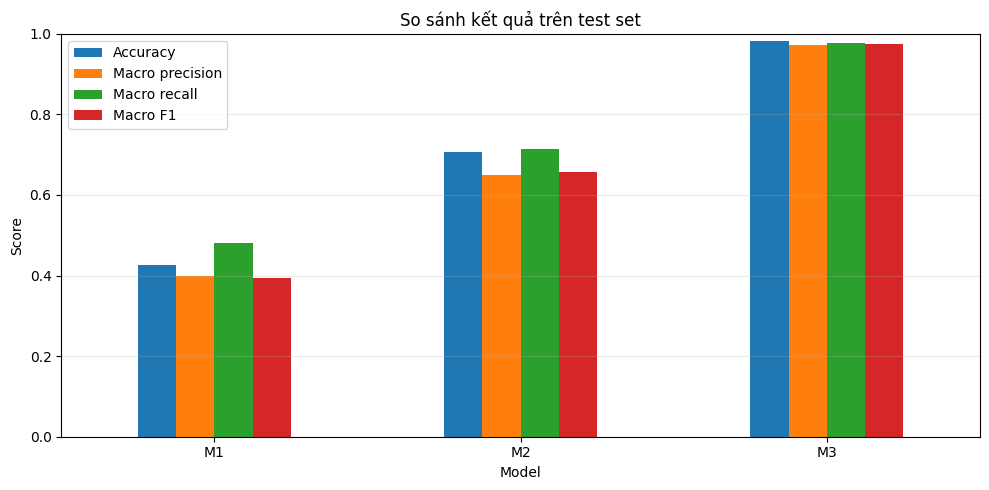

In [4]:
if comparison.empty:
    raise RuntimeError("Chưa có kết quả để so sánh.")
display(comparison.style.format("{:.4f}").background_gradient(cmap="Blues"))
ax = comparison.plot(kind="bar", figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_ylabel("Score")
ax.set_title("So sánh kết quả trên test set")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

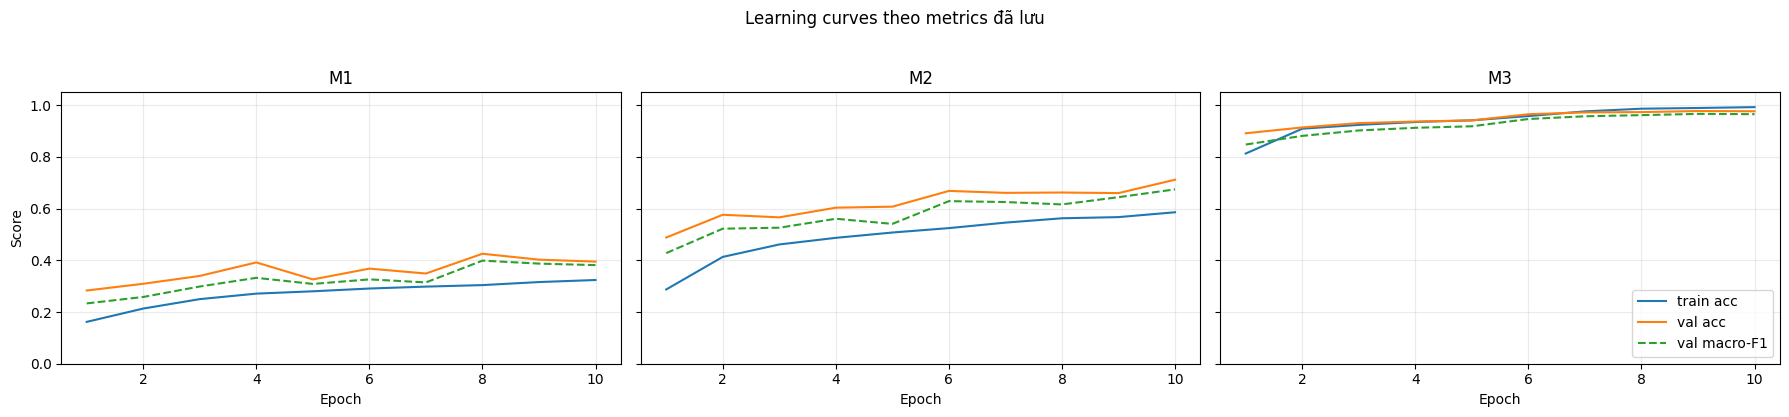

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    history = training.get(model)
    if not history or not history.get("history"):
        ax.set_title(f"{model} (chưa có history)")
        ax.axis("off")
        continue
    h = pd.DataFrame(history["history"])
    ax.plot(h["epoch"], h["train_accuracy"], label="train acc")
    ax.plot(h["epoch"], h["val_accuracy"], label="val acc")
    ax.plot(h["epoch"], h["val_macro_f1"], label="val macro-F1", linestyle="--")
    ax.set_title(model)
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="lower right")
fig.suptitle("Learning curves theo metrics đã lưu", y=1.03)
plt.tight_layout()
plt.show()

## 3. Confusion matrix và lỗi theo lớp

Confusion matrix được sinh bởi [`src/evaluate.py`](../src/evaluate.py). Hàng là nhãn thật, cột là nhãn dự đoán; các ô ngoài đường chéo cho biết những cặp lớp dễ nhầm.

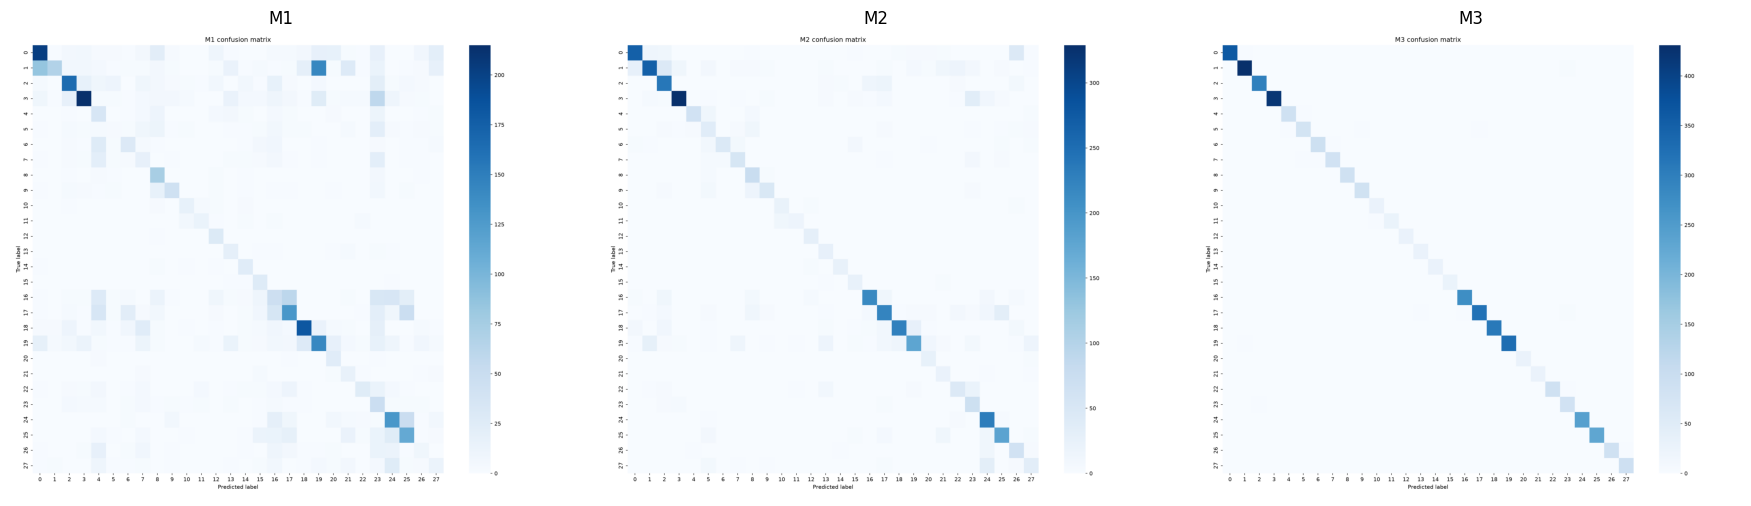

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))
axes = np.atleast_1d(axes)
for ax, model in zip(axes, models):
    image_path = PLOTS / f"{model}_confusion_matrix.png"
    if image_path.is_file():
        ax.imshow(plt.imread(image_path))
        ax.set_title(model)
        ax.axis("off")
    else:
        ax.set_title(f"{model}: chưa có ảnh")
        ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
best_model = comparison["Macro F1"].idxmax()
best_report = evaluation[best_model].get("classification_report", {})
per_class = pd.DataFrame([
    {"class_name": name, "precision": values.get("precision", np.nan), "recall": values.get("recall", np.nan), "f1": values.get("f1-score", np.nan), "support": values.get("support", np.nan)}
    for name, values in best_report.items() if isinstance(values, dict) and "f1-score" in values
]).sort_values("f1")
print(f"Model tốt nhất theo test macro-F1: {best_model}")
display(per_class.head(10).style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "support": "{:.0f}"}))

Model tốt nhất theo test macro-F1: M3


,class_name,precision,recall,f1,support
23,Potato__Rotten,0.865,0.933,0.897,89
5,Bellpepper__Rotten,0.908,0.888,0.898,89
7,Carrot__Rotten,0.954,0.933,0.943,89
9,Cucumber__Rotten,0.944,0.977,0.960,87
4,Bellpepper__Healthy,0.957,0.967,0.962,91
11,Grape__Rotten,1.000,0.933,0.966,30
15,Jujube__Rotten,1.000,0.933,0.966,30
10,Grape__Healthy,0.938,1.000,0.968,30
13,Guava__Rotten,0.938,1.000,0.968,30
27,Tomato__Rotten,0.957,0.989,0.973,91


## 4. Kết luận

- **M3 là lựa chọn tốt nhất về hiệu năng**: transfer learning với MobileNetV2 đạt macro-F1 cao nhất, vượt rõ rệt M2 và M1.
- **M2 cải thiện đáng kể so với baseline** nhờ convolution và pooling, cho thấy đặc trưng không gian quan trọng với ảnh rau củ quả.
- **M1 phù hợp làm baseline kiểm chứng pipeline**, nhưng flatten ảnh làm mất quan hệ không gian nên không nên là lựa chọn triển khai khi ưu tiên chất lượng.
- Khi triển khai, không nên chỉ nhìn accuracy: cần theo dõi macro-F1, per-class recall và các ô ngoài đường chéo của confusion matrix; ưu tiên kiểm tra những lớp có F1 thấp.
- Kết quả hiện tại phản ánh checkpoint và split hiện có. Cần báo cáo thêm thời gian/số tham số/kích thước model nếu quyết định theo trade-off latency–accuracy; đồng thời xác thực trên ảnh ngoài dataset trước khi kết luận về production.

In [8]:
best = comparison["Macro F1"].idxmax()
worst = comparison["Macro F1"].idxmin()
summary = (
    f"Theo test macro-F1, {best} đứng đầu ({comparison.loc[best, 'Macro F1']:.4f}), "
    f"còn {worst} thấp nhất ({comparison.loc[worst, 'Macro F1']:.4f}). "
    "Kết luận này nên được đọc cùng per-class report và confusion matrix."
)
print(summary)

Theo test macro-F1, M3 đứng đầu (0.9745), còn M1 thấp nhất (0.3928). Kết luận này nên được đọc cùng per-class report và confusion matrix.
